# Reproduction "bxy360 -- right"


In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import module.rb85_bloch as rb85_bloch
import qt_app.physics as physics

importlib.reload(rb85_bloch)
importlib.reload(physics)

<module 'qt_app.physics' from '/Users/alban/Library/Mobile Documents/com~apple~CloudDocs/ENSCP/Stage Glasgow/sim_project/Rb85_bloch_sim/qt_app/physics.py'>

## Paramètres


In [ ]:
# --- paramètres "simulation actuelle" ---
pump_pol = 'R'          # polarisation de la pompe 
pump_s = 0.6             # paramètre de saturation de la pompe
pump_det_MHz = 0.0        # détuning de pompe
gamma_t = 3.0e4           # taux de relaxation de transit (s^-1)
n_rho = 5.383e13          # densité atomique (m^-3)
L_cell_mm = 75.0          # longueur de cellule (mm)
probe_det_MHz = 0.0       # détuning de sonde (mesure "sur résonance")

cut_theta_deg = 0.0       # coupe de Poincaré 
cut_phi_deg = 90.0

# --- conditions de la mesure bxy360 : Bxy tournant dans le plan transverse, Bz=0 ---
COIL_GAIN_G_PER_A = 0.687   #G/A
Bz_shift = -1
r_list_A = [0.15, 0.18, 0.22, 0.25, 0.29, 0.33, 0.36, 0.4, 0.44]   # courant, A (légende du graphe)
drive_angle_deg = np.linspace(0.0, 360.0, 30, endpoint=False)      # "Drive angle theta"

pump_det_rad = 2 * np.pi * pump_det_MHz * 1e6
probe_det_rad = np.array([2 * np.pi * probe_det_MHz * 1e6])
L_cell = L_cell_mm * 1e-3

e1, e2 = physics.make_cut(np.radians(cut_theta_deg), np.radians(cut_phi_deg))
E_in = physics.E_in_on_cut(e1, e2)

## Visualisation des champs B vs axe de propagation

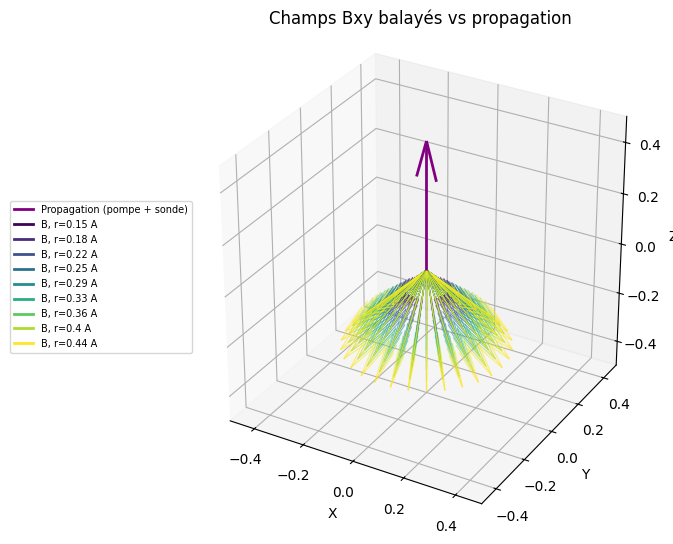

In [ ]:
from mpl_toolkits.mplot3d import Axes3D 

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

K_vec = np.array([0, 0, 0.5])   # axe de propagation pompe + sonde = axe de quantification
ax.quiver(0, 0, 0, K_vec[0], K_vec[1], K_vec[2], color="purple", linewidth=2,
          label="Propagation (pompe + sonde)")

# pour chaque courant r_A, tracé aux angles de drive_angle_deg
colors_r = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

for r_A, color in zip(r_list_A, colors_r):
    B_norm_G = r_A * COIL_GAIN_G_PER_A
    for theta in drive_angle_deg:
        th = np.radians(theta)
        B_vec_G = B_norm_G * np.array([np.cos(th), np.sin(th), Bz_shift])
        ax.quiver(0, 0, 0, B_vec_G[0], B_vec_G[1], B_vec_G[2],
                  color=color, linewidth=0.8, alpha=0.6)

lim = max(0.5, max(r_list_A) * COIL_GAIN_G_PER_A)
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([-lim, lim])
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Champs Bxy balayés vs propagation")

# légende : proxy pour l'éventail de B (une entrée par courant) + la propagation
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color="purple", lw=2, label="Propagation (pompe + sonde)")]
handles += [Line2D([0], [0], color=c, lw=2, label=f"B, r={r_A} A") for r_A, c in zip(r_list_A, colors_r)]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(-0.35, 0.5), fontsize=7, ncol=1)

fig.tight_layout()
plt.show()

## Balayage


In [4]:
component_styles = [
    ('H', 'tab:blue',   '-'),
    ('V', 'tab:orange', '-'),
    ('R', 'tab:green',  '--'),
    ('L', 'tab:red',    '--'),
    ('D', 'tab:purple', ':'),
    ('A', 'tab:brown',  ':'),
]

results_deg = {ch: {} for ch, _, _ in component_styles}

for r_A in r_list_A:
    B_norm_T = r_A * COIL_GAIN_G_PER_A * 1e-4
    thetas = {ch: [] for ch, _, _ in component_styles}
    for theta in drive_angle_deg:
        th = np.radians(theta)
        B_T = B_norm_T * np.array([np.cos(th), np.sin(th), Bz_shift])

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_all = rb85_bloch.polarization_intensities(E_out)

        for ch, _, _ in component_styles:
            phase_rad, amp = physics._fit_phase(I_all[ch])
            thetas[ch].append(abs(np.degrees(phase_rad)))

    for ch, _, _ in component_styles:
        results_deg[ch][r_A] = np.array(thetas[ch])

## Tracé 

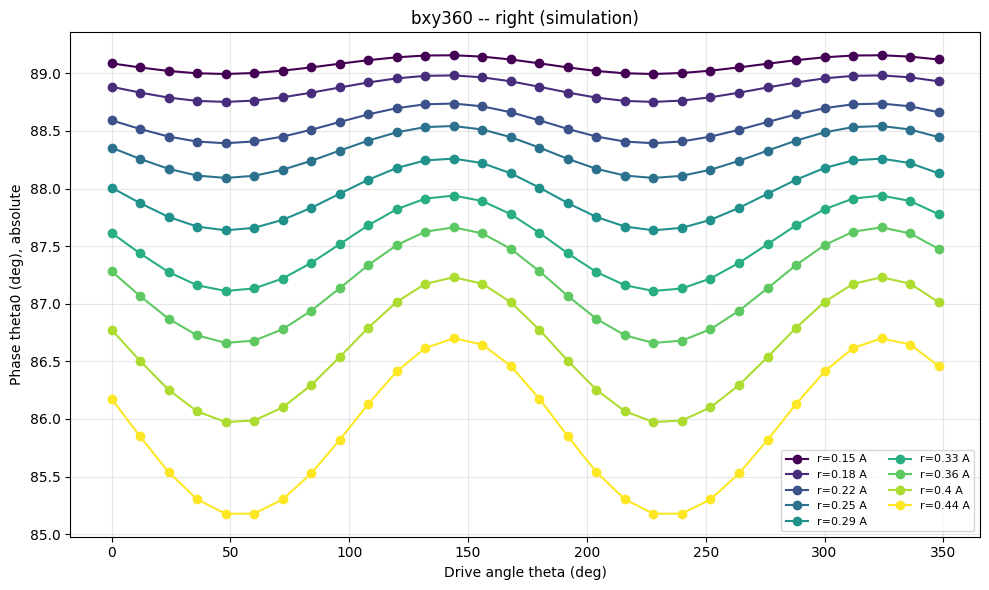

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

for r_A, color in zip(r_list_A, colors):
    ax.plot(drive_angle_deg, results_deg['V'][r_A], marker='o', color=color, label=f'r={r_A} A')

ax.set_title('bxy360 -- right (simulation)')
ax.set_xlabel('Drive angle theta (deg)')
ax.set_ylabel('Phase theta0 (deg), absolute')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Tracé -- projection H et autres canaux

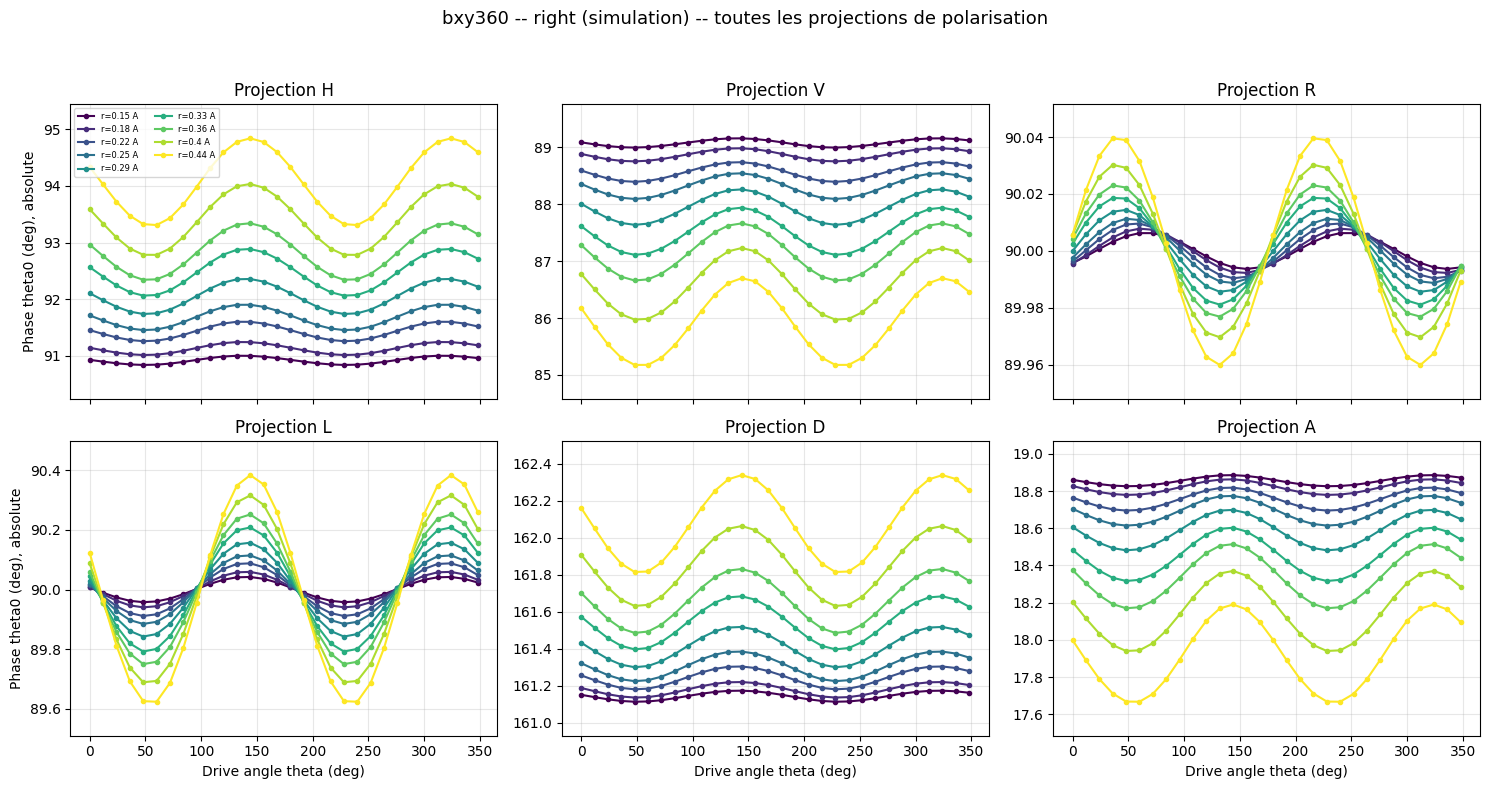

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

for ax, (ch, _, _) in zip(axs.flat, component_styles):
    for r_A, color in zip(r_list_A, colors):
        ax.plot(drive_angle_deg, results_deg[ch][r_A], marker='o', markersize=3,
                color=color, label=f'r={r_A} A')
    ax.set_title(f'Projection {ch}')
    ax.grid(True, alpha=0.3)
    ax.margins(y=0.15)

for ax in axs[-1, :]:
    ax.set_xlabel('Drive angle theta (deg)')
for ax in axs[:, 0]:
    ax.set_ylabel('Phase theta0 (deg), absolute')

axs.flat[0].legend(ncol=2, fontsize=6)
fig.suptitle('bxy360 -- right (simulation) -- toutes les projections de polarisation', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Angle de biréfringence (par vecteur B)

Pour chaque B (chaque `r_A`, `drive_angle`), angle de biréfringence = phi(H) - phi(V), à partir des phases déjà calculées dans le Balayage ci-dessus (`results_deg`).

In [7]:
biref_deg = {r_A: results_deg['H'][r_A] - results_deg['V'][r_A] for r_A in r_list_A}

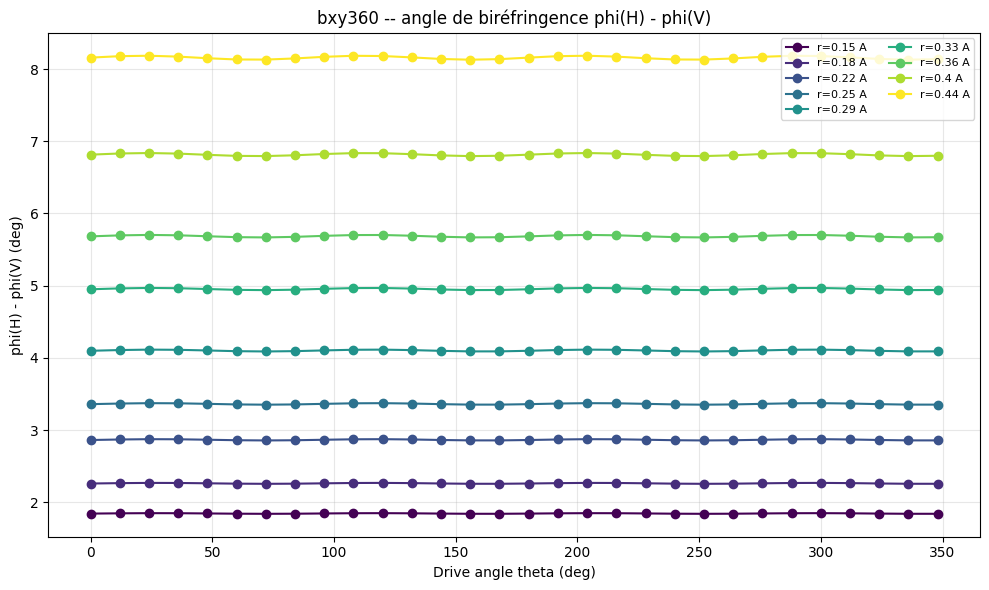

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

for r_A, color in zip(r_list_A, colors):
    ax.plot(drive_angle_deg, biref_deg[r_A], marker='o', color=color, label=f'r={r_A} A')

ax.set_title('bxy360 -- angle de biréfringence phi(H) - phi(V)')
ax.set_xlabel('Drive angle theta (deg)')
ax.set_ylabel('phi(H) - phi(V) (deg)')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Inclinaison du plan de rotation de B (effet Faraday)

Jusqu'ici Bxy tourne dans le plan transverse pur (X,Y), avec un biais longitudinal fixe `Bz_shift`. On incline maintenant le plan de rotation autour de l'axe X d'un angle `tilt_deg` : la composante tournante acquiert alors une projection sur l'axe de propagation qui varie avec l'angle de drive, ce qui ajoute un peu d'effet Faraday (modulé par theta) en plus du biais constant.

In [9]:
# --- paramètres de l'inclinaison ---
tilt_deg = 15.0            # inclinaison du plan de rotation vs plan transverse, autour de l'axe X (deg)
tilt_list_deg = [0.0, 5.0, 10.0, 15.0, 20.0, 30.0]   # comparaison pour plusieurs inclinaisons
r_A_tilt = r_list_A[-1]    # courant fixé pour isoler l'effet du tilt (signal le plus fort)


def B_T_rotating_tilted(B_norm_T, theta_deg, tilt_deg_i, Bz_shift):
    """Champ B (T) : cercle de rayon B_norm_T tournant dans un plan incliné de
    tilt_deg_i autour de l'axe X, plus le biais longitudinal Bz_shift*B_norm_T.
    tilt_deg_i=0 redonne exactement la rotation transverse pure utilisée plus haut."""
    th = np.radians(theta_deg)
    tr = np.radians(tilt_deg_i)
    u_hat = np.array([1.0, 0.0, 0.0])
    v_hat = np.array([0.0, np.cos(tr), np.sin(tr)])
    ez = np.array([0.0, 0.0, 1.0])
    return B_norm_T * (np.cos(th) * u_hat + np.sin(th) * v_hat + Bz_shift * ez)

### Visualisation du plan incliné vs propagation

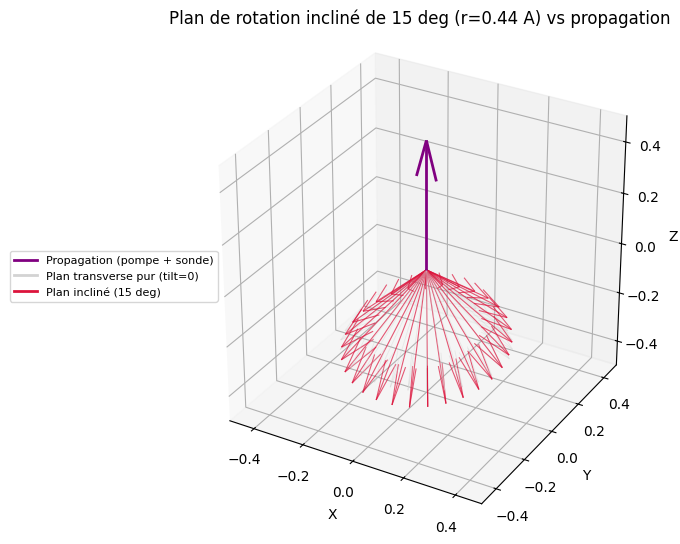

In [10]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

K_vec = np.array([0, 0, 0.5])
ax.quiver(0, 0, 0, K_vec[0], K_vec[1], K_vec[2], color="purple", linewidth=2,
          label="Propagation (pompe + sonde)")

B_norm_G_tilt = r_A_tilt * COIL_GAIN_G_PER_A

# référence : plan transverse pur (tilt=0), en gris clair
for theta in drive_angle_deg:
    B_vec_G = B_T_rotating_tilted(B_norm_G_tilt, theta, 0.0, Bz_shift)
    ax.quiver(0, 0, 0, B_vec_G[0], B_vec_G[1], B_vec_G[2],
              color="lightgray", linewidth=0.6, alpha=0.4)

# plan incliné de tilt_deg
for theta in drive_angle_deg:
    B_vec_G = B_T_rotating_tilted(B_norm_G_tilt, theta, tilt_deg, Bz_shift)
    ax.quiver(0, 0, 0, B_vec_G[0], B_vec_G[1], B_vec_G[2],
              color="crimson", linewidth=0.8, alpha=0.7)

lim = max(0.5, B_norm_G_tilt * 1.5)
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([-lim, lim])
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f"Plan de rotation incliné de {tilt_deg:g} deg (r={r_A_tilt} A) vs propagation")

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color="purple", lw=2, label="Propagation (pompe + sonde)"),
    Line2D([0], [0], color="lightgray", lw=2, label="Plan transverse pur (tilt=0)"),
    Line2D([0], [0], color="crimson", lw=2, label=f"Plan incliné ({tilt_deg:g} deg)"),
]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(-0.35, 0.5), fontsize=8)

fig.tight_layout()
plt.show()

### Balayage (avec tilt, r fixé)

In [11]:
B_norm_T_tilt = r_A_tilt * COIL_GAIN_G_PER_A * 1e-4

results_deg_tilt = {t: {ch: [] for ch, _, _ in component_styles} for t in tilt_list_deg}

for tilt_deg_i in tilt_list_deg:
    for theta in drive_angle_deg:
        B_T = B_T_rotating_tilted(B_norm_T_tilt, theta, tilt_deg_i, Bz_shift)

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_all = rb85_bloch.polarization_intensities(E_out)

        for ch, _, _ in component_styles:
            phase_rad, amp = physics._fit_phase(I_all[ch])
            results_deg_tilt[tilt_deg_i][ch].append(abs(np.degrees(phase_rad)))

for tilt_deg_i in tilt_list_deg:
    for ch, _, _ in component_styles:
        results_deg_tilt[tilt_deg_i][ch] = np.array(results_deg_tilt[tilt_deg_i][ch])

### Tracé -- effet du tilt sur la projection V

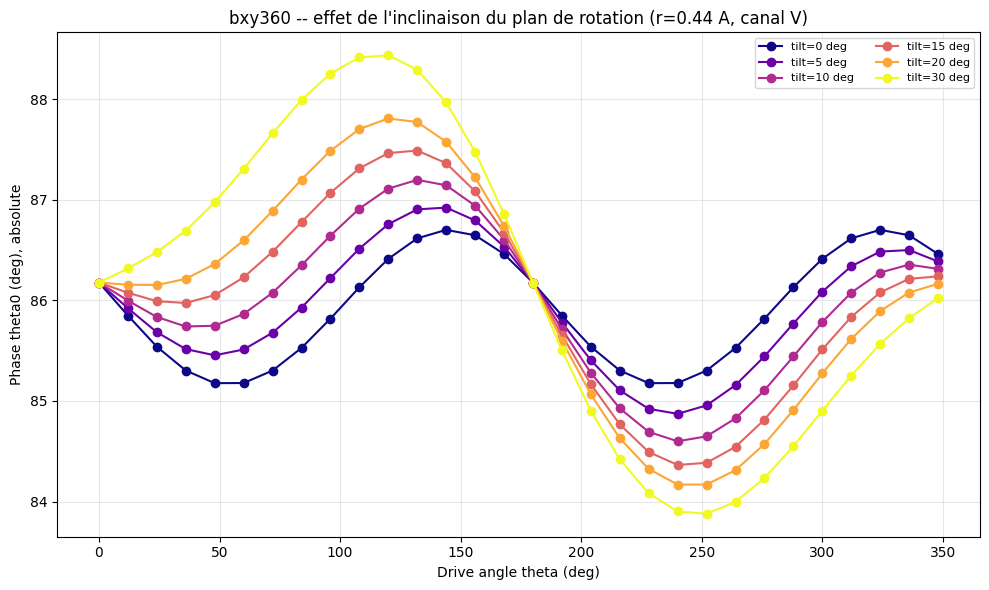

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_tilt = plt.cm.plasma(np.linspace(0, 1, len(tilt_list_deg)))

for tilt_deg_i, color in zip(tilt_list_deg, colors_tilt):
    ax.plot(drive_angle_deg, results_deg_tilt[tilt_deg_i]['V'], marker='o', color=color,
            label=f'tilt={tilt_deg_i:g} deg')

ax.set_title(f"bxy360 -- effet de l'inclinaison du plan de rotation (r={r_A_tilt} A, canal V)")
ax.set_xlabel('Drive angle theta (deg)')
ax.set_ylabel('Phase theta0 (deg), absolute')
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Tracé -- effet du tilt sur les six projections

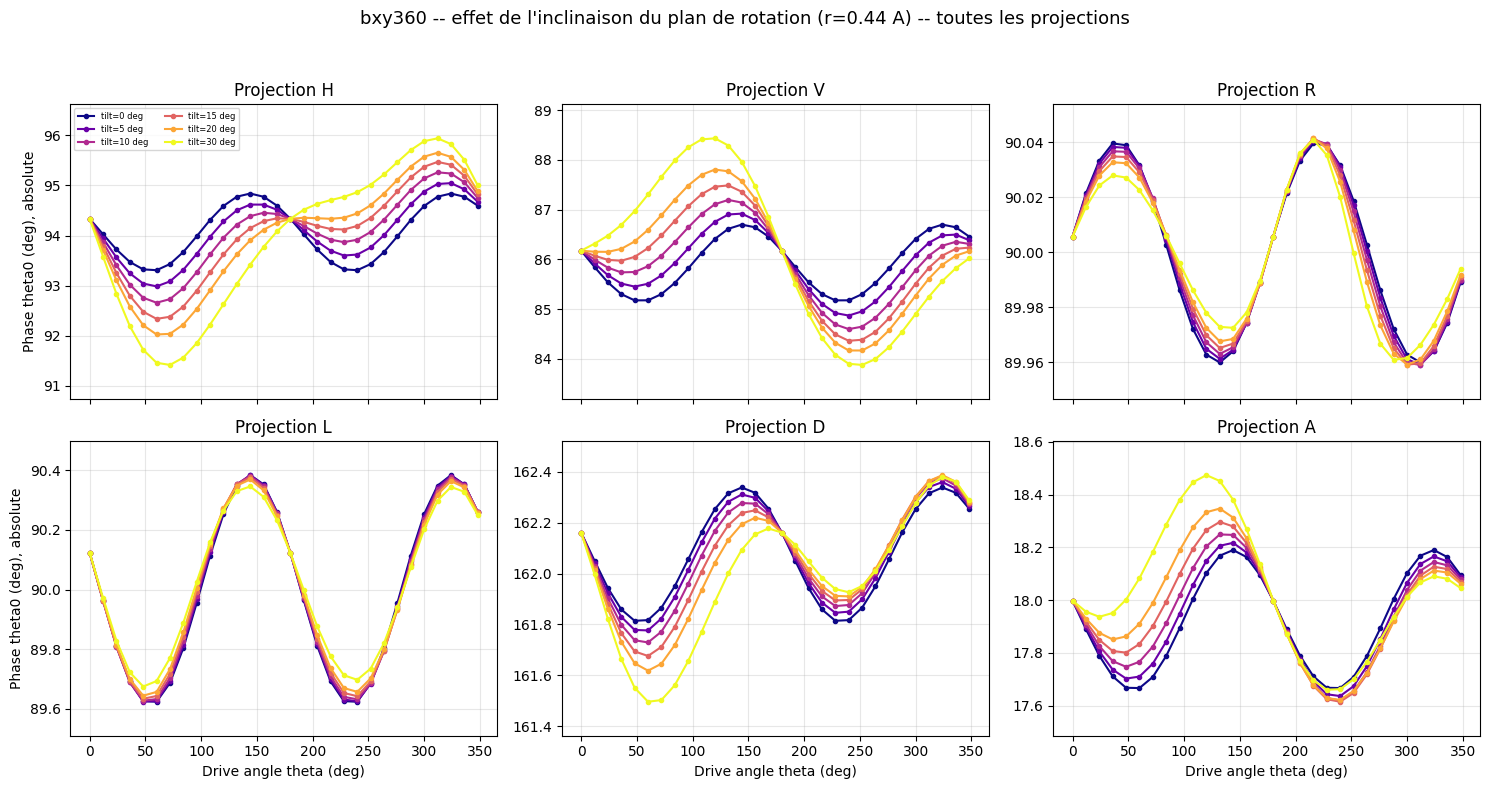

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
colors_tilt = plt.cm.plasma(np.linspace(0, 1, len(tilt_list_deg)))

for ax, (ch, _, _) in zip(axs.flat, component_styles):
    for tilt_deg_i, color in zip(tilt_list_deg, colors_tilt):
        ax.plot(drive_angle_deg, results_deg_tilt[tilt_deg_i][ch], marker='o', markersize=3,
                color=color, label=f'tilt={tilt_deg_i:g} deg')
    ax.set_title(f'Projection {ch}')
    ax.grid(True, alpha=0.3)
    ax.margins(y=0.15)

for ax in axs[-1, :]:
    ax.set_xlabel('Drive angle theta (deg)')
for ax in axs[:, 0]:
    ax.set_ylabel('Phase theta0 (deg), absolute')

axs.flat[0].legend(ncol=2, fontsize=6)
fig.suptitle(f"bxy360 -- effet de l'inclinaison du plan de rotation (r={r_A_tilt} A) -- toutes les projections",
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### Balayage (avec tilt fixe, sweep sur r_A) -- même format que la version non inclinée

In [14]:
results_deg_plan = {ch: {} for ch, _, _ in component_styles}

for r_A in r_list_A:
    B_norm_T = r_A * COIL_GAIN_G_PER_A * 1e-4
    thetas = {ch: [] for ch, _, _ in component_styles}
    for theta in drive_angle_deg:
        B_T = B_T_rotating_tilted(B_norm_T, theta, tilt_deg, Bz_shift)

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_all = rb85_bloch.polarization_intensities(E_out)

        for ch, _, _ in component_styles:
            phase_rad, amp = physics._fit_phase(I_all[ch])
            thetas[ch].append(abs(np.degrees(phase_rad)))

    for ch, _, _ in component_styles:
        results_deg_plan[ch][r_A] = np.array(thetas[ch])

### Tracé -- six projections vs r_A (plan incliné de tilt_deg)

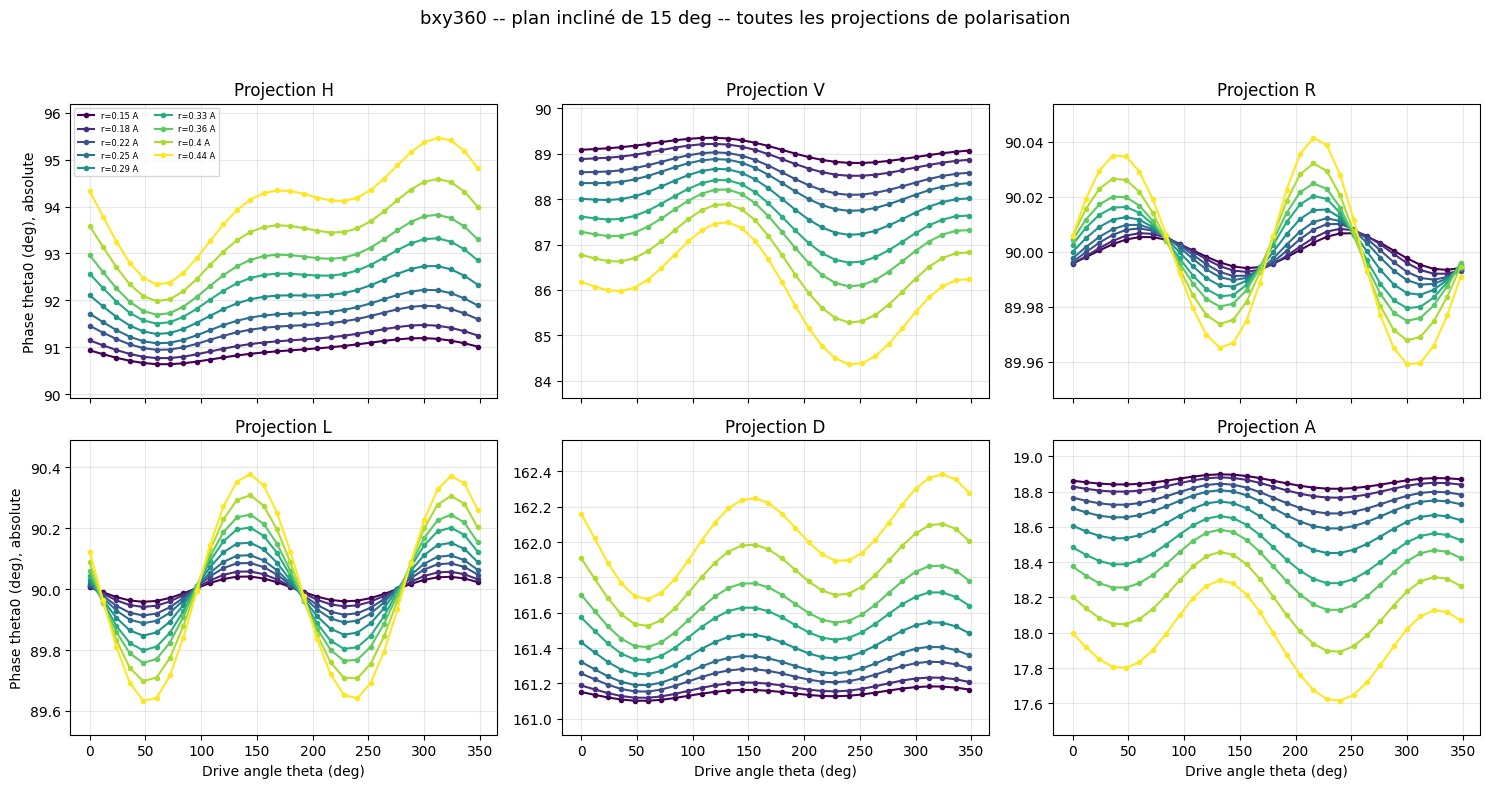

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

for ax, (ch, _, _) in zip(axs.flat, component_styles):
    for r_A, color in zip(r_list_A, colors):
        ax.plot(drive_angle_deg, results_deg_plan[ch][r_A], marker='o', markersize=3,
                color=color, label=f'r={r_A} A')
    ax.set_title(f'Projection {ch}')
    ax.grid(True, alpha=0.3)
    ax.margins(y=0.15)

for ax in axs[-1, :]:
    ax.set_xlabel('Drive angle theta (deg)')
for ax in axs[:, 0]:
    ax.set_ylabel('Phase theta0 (deg), absolute')

axs.flat[0].legend(ncol=2, fontsize=6)
fig.suptitle(f'bxy360 -- plan incliné de {tilt_deg:g} deg -- toutes les projections de polarisation', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Intensité angulaire I(theta_cut) -- une figure par norme de B

Un graphe (grille des 6 canaux) par `r_A` (3 valeurs choisies dans `r_list_A`) ; dans chaque graphe, couleur = `drive_angle` (colormap cyclique `hsv`).

/var/folders/zj/r36g0vwn2hn7msjrfcd_ksk40000gn/T/ipykernel_93285/4214513677.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.9, 0.95))


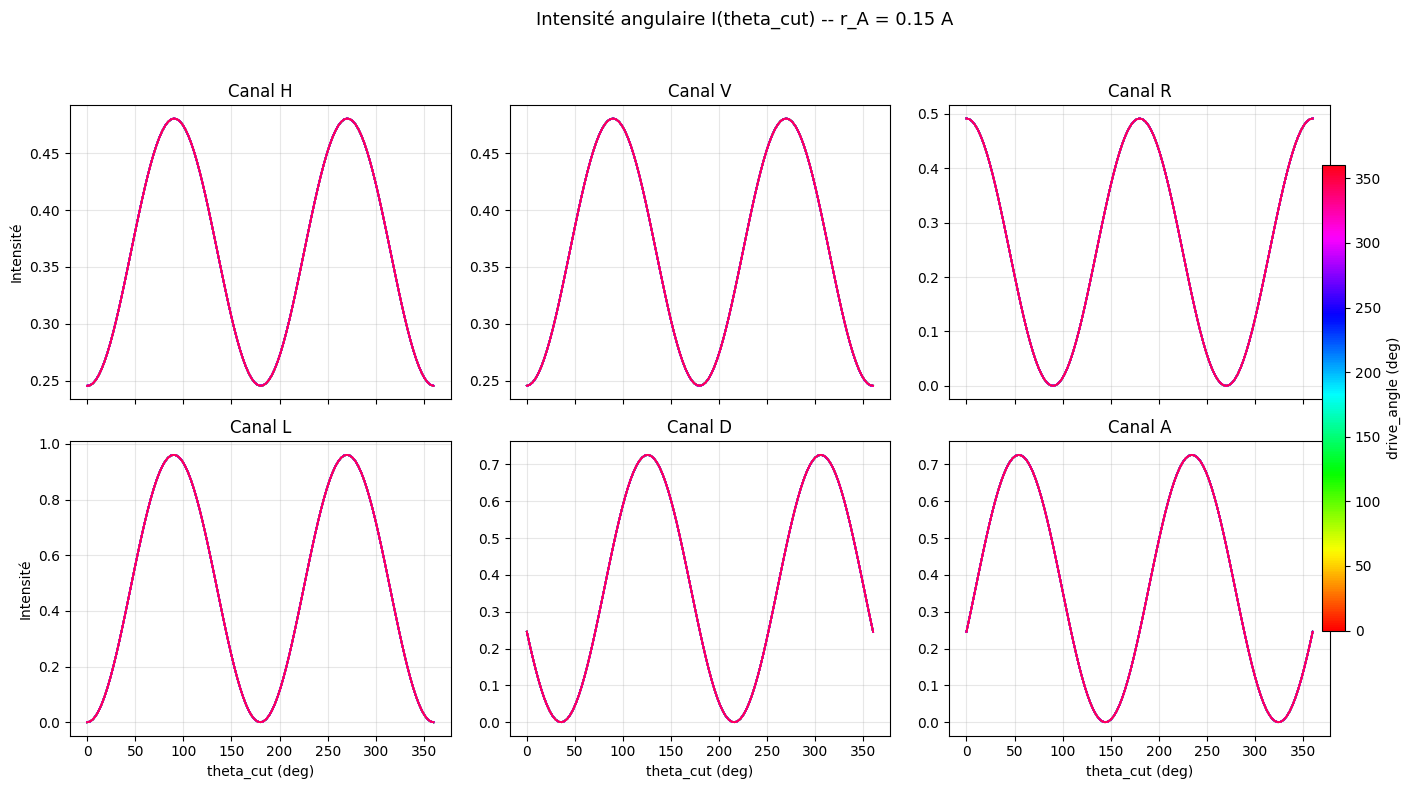

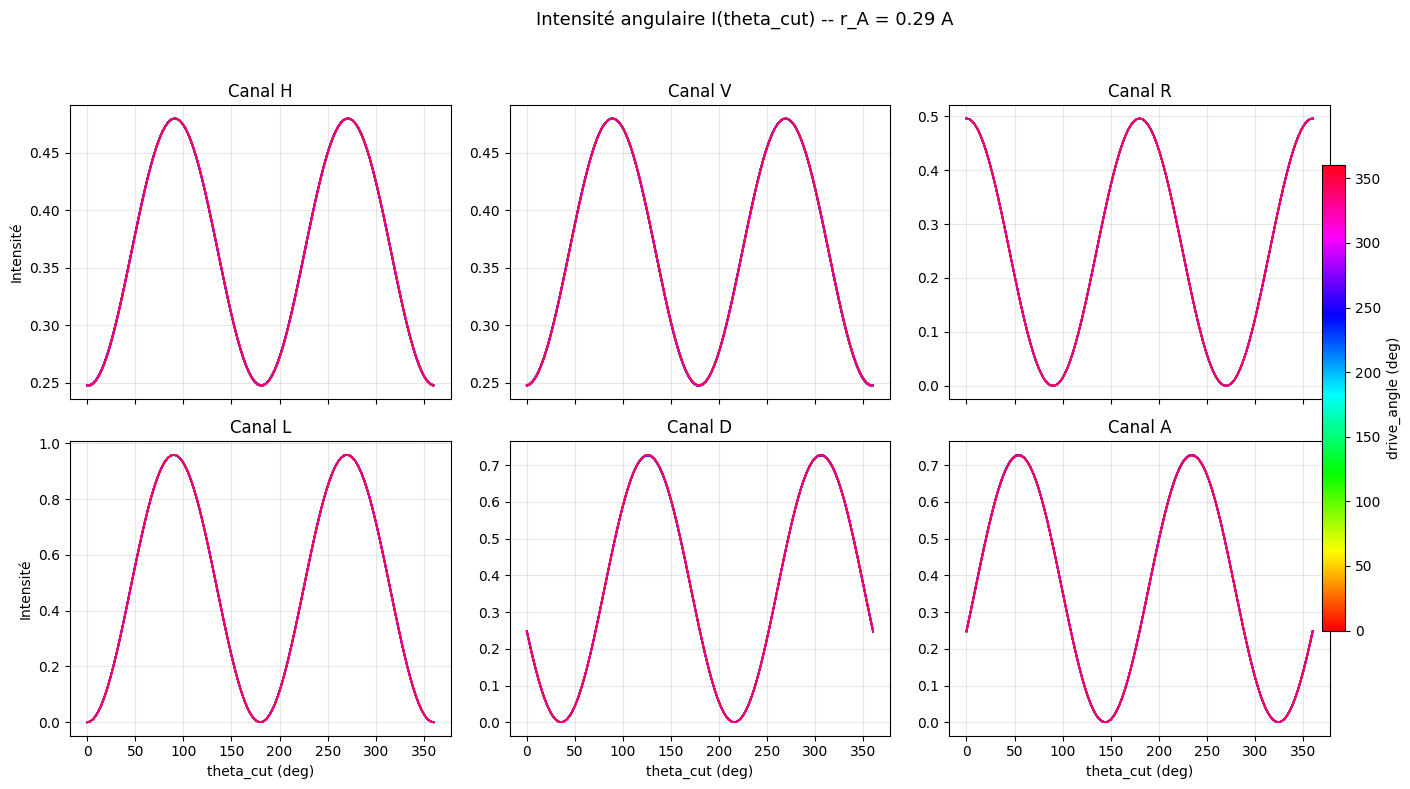

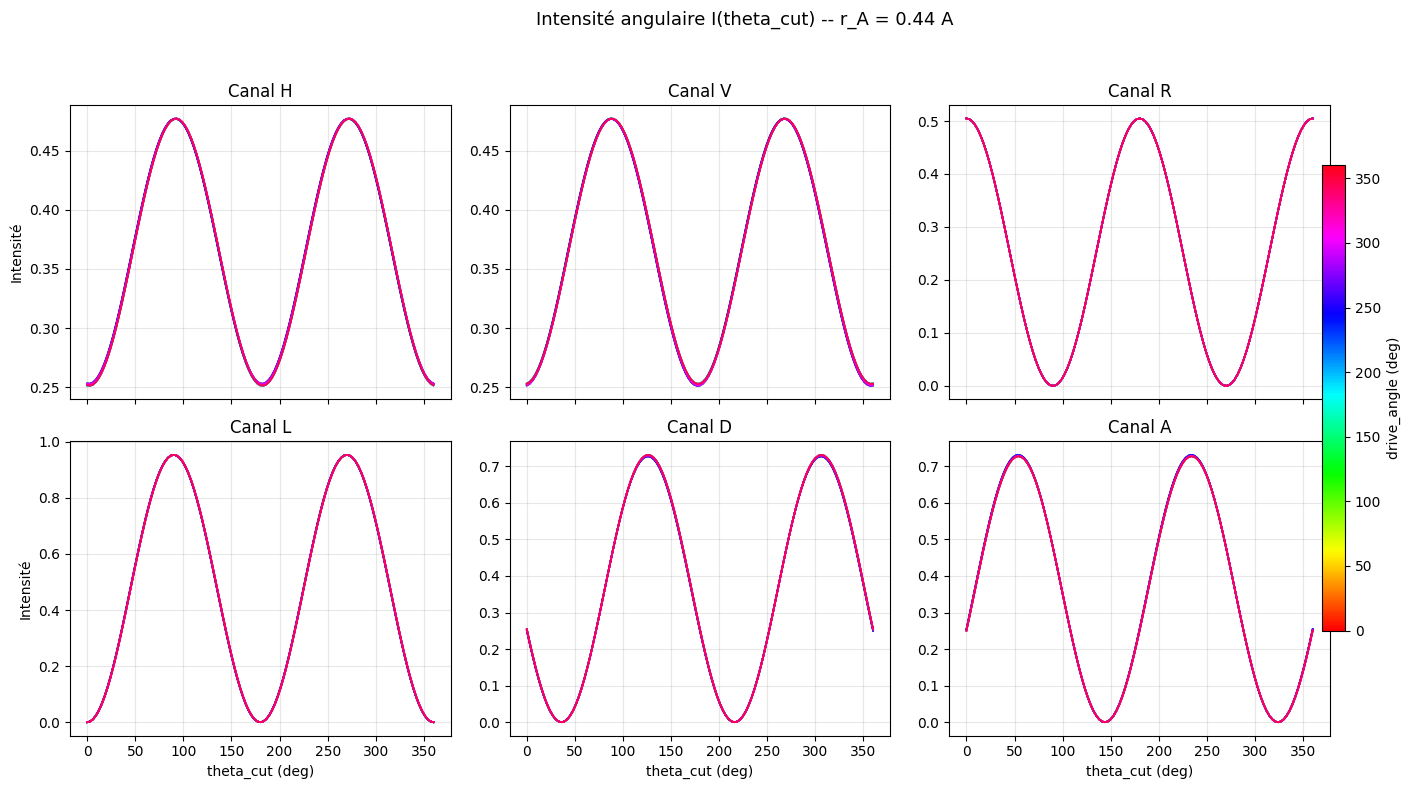

In [16]:
theta_cut_deg = np.degrees(physics.theta_values)
r_A_sel = [r_list_A[0], r_list_A[len(r_list_A) // 2], r_list_A[-1]]   # 3 normes choisies

for r_A in r_A_sel:
    B_norm_T = r_A * COIL_GAIN_G_PER_A * 1e-4

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    ax_by_ch = dict(zip([ch for ch, _, _ in component_styles], axs.flat))

    for theta in drive_angle_deg:
        color = plt.cm.hsv(theta / 360.0)
        th = np.radians(theta)
        B_T = B_norm_T * np.array([np.cos(th), np.sin(th), Bz_shift])

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_all = rb85_bloch.polarization_intensities(E_out)

        for ch, _, _ in component_styles:
            ax_by_ch[ch].plot(theta_cut_deg, I_all[ch], color=color, linewidth=1.2, alpha=0.8)

    for ch, ax in ax_by_ch.items():
        ax.set_title(f'Canal {ch}')
        ax.grid(True, alpha=0.3)

    for ax in axs[-1, :]:
        ax.set_xlabel('theta_cut (deg)')
    for ax in axs[:, 0]:
        ax.set_ylabel('Intensité')

    sm = plt.cm.ScalarMappable(cmap='hsv', norm=plt.Normalize(0, 360))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.03)
    cbar.set_label('drive_angle (deg)')

    fig.suptitle(f'Intensité angulaire I(theta_cut) -- r_A = {r_A} A', fontsize=13)
    fig.tight_layout(rect=(0, 0, 0.9, 0.95))
    plt.show()

### Zoom sur le déphasage (grille fine, près d'un pic) -- canaux H et V

Le décalage est réel mais sous-degré sur `theta_cut` (voir l'écart de phase déjà quantifié plus haut) -- invisible sur 0-360°. On ré-échantillonne la coupe de Poincaré beaucoup plus finement (500 points sur une fenêtre de 25° au lieu de 121 points sur 360°) et on zoome sur le pic de chaque canal (H et V, dont les pics ne sont pas au même `theta_cut`), pour les 3 normes de B déjà choisies.

/var/folders/zj/r36g0vwn2hn7msjrfcd_ksk40000gn/T/ipykernel_93285/2986969885.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.9, 0.96))


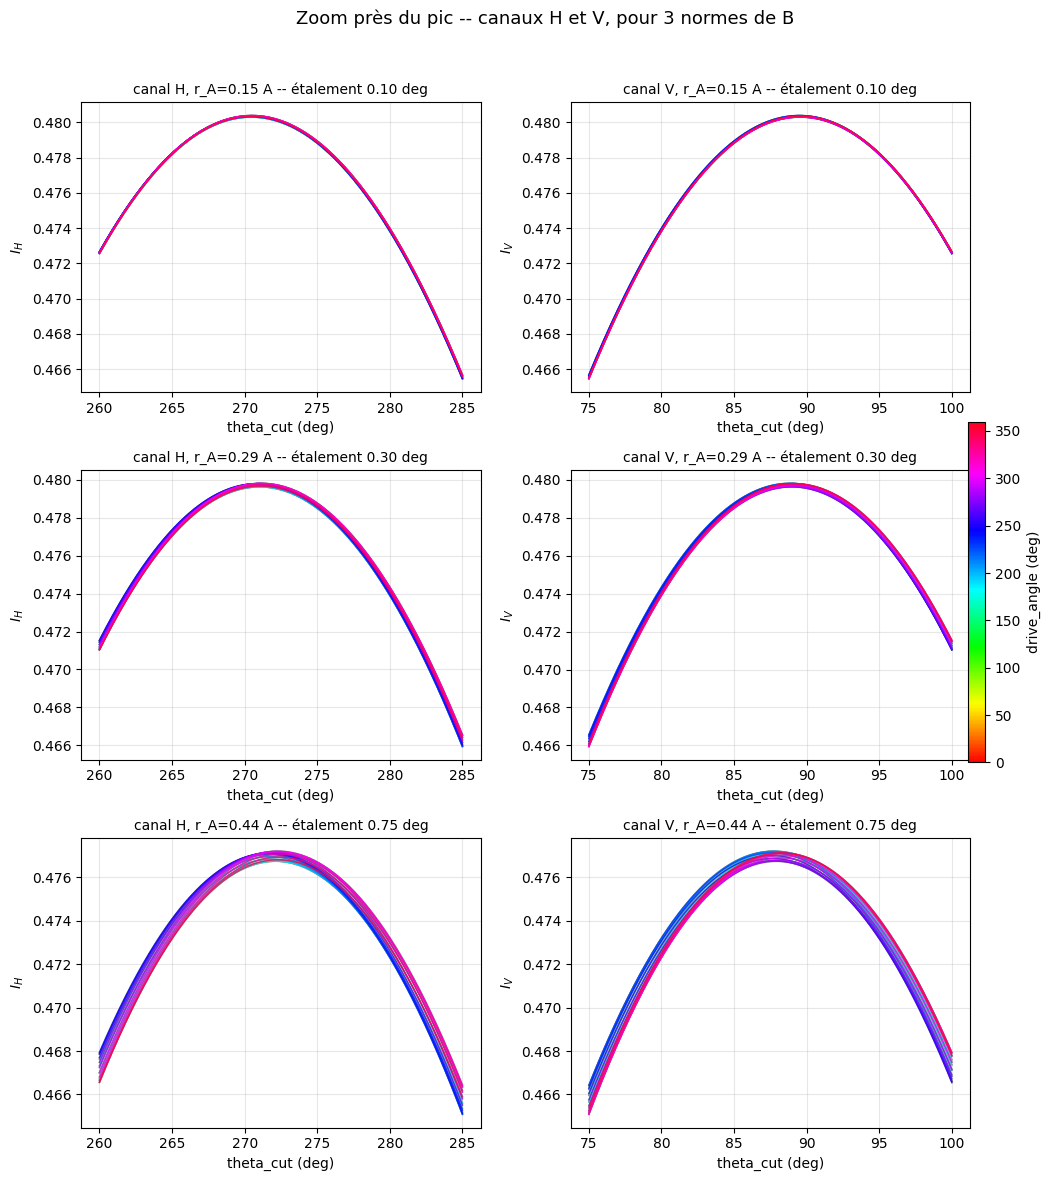

In [17]:
def E_in_on_cut_fine(e1, e2, theta_arr):
    """Comme physics.E_in_on_cut, mais sur une grille theta arbitraire (pour zoomer)."""
    E = np.empty((len(theta_arr), 2), dtype=complex)
    for i, th in enumerate(theta_arr):
        s1, s2, s3 = np.cos(2 * th) * e1 + np.sin(2 * th) * e2
        alpha = np.arccos(np.clip(s1, -1.0, 1.0)) / 2
        delta = np.arctan2(s3, s2)
        E[i] = [np.cos(alpha), np.sin(alpha) * np.exp(1j * delta)]
    return E

channels_zoom = ['H', 'V']
zoom_window_deg = {'H': (260, 285), 'V': (75, 100)}   # H et V ne pic pas au même theta_cut
theta_fine_deg_by_ch = {ch: np.linspace(*zoom_window_deg[ch], 500) for ch in channels_zoom}
E_in_fine_by_ch = {
    ch: E_in_on_cut_fine(e1, e2, np.radians(theta_fine_deg_by_ch[ch])) for ch in channels_zoom
}

fig, axs = plt.subplots(len(r_A_sel), len(channels_zoom), figsize=(11, 4 * len(r_A_sel)))

for row, r_A_zoom in enumerate(r_A_sel):
    B_norm_T_zoom = r_A_zoom * COIL_GAIN_G_PER_A * 1e-4
    for col, ch in enumerate(channels_zoom):
        ax = axs[row, col]
        theta_fine_deg = theta_fine_deg_by_ch[ch]
        E_in_fine = E_in_fine_by_ch[ch]
        peak_thetas = []
        for theta in drive_angle_deg:
            color = plt.cm.hsv(theta / 360.0)
            th = np.radians(theta)
            B_T = B_norm_T_zoom * np.array([np.cos(th), np.sin(th), Bz_shift])

            J = rb85_bloch.jones_matrix_closed(
                probe_det_rad, B_T, pump_s, L_cell, n_rho,
                pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
            )
            E_out = np.einsum('ij,tj->ti', J[0], E_in_fine)
            I_ch = rb85_bloch.polarization_intensities(E_out)[ch]
            ax.plot(theta_fine_deg, I_ch, color=color, linewidth=1.1, alpha=0.8)
            peak_thetas.append(theta_fine_deg[np.argmax(I_ch)])

        peak_thetas = np.array(peak_thetas)
        ax.set_title(f"canal {ch}, r_A={r_A_zoom} A -- étalement "
                     f"{peak_thetas.max() - peak_thetas.min():.2f} deg", fontsize=10)
        ax.set_xlabel('theta_cut (deg)')
        ax.set_ylabel(f'$I_{{{ch}}}$')
        ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap='hsv', norm=plt.Normalize(0, 360))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.03)
cbar.set_label('drive_angle (deg)')

fig.suptitle('Zoom près du pic -- canaux H et V, pour 3 normes de B', fontsize=13)
fig.tight_layout(rect=(0, 0, 0.9, 0.96))
plt.show()

## Harmoniques H2 et H4 de phi_V(drive_angle) -- amplitude et phase (FFT)

FFT de `phi_V` (phase brute, non valeur absolue) le long de `drive_angle` (0-360°), pour chaque `r_A`. On reconstruit et trace `A_k * cos(k*theta + phi_k)` pour k=2 (H2) et k=4 (H4) : la hauteur de la courbe donne l'amplitude, son décalage horizontal donne la phase. Même axe horizontal (drive_angle, 0-360°) et même code couleur par `r_A` (viridis) que les tracés précédents.

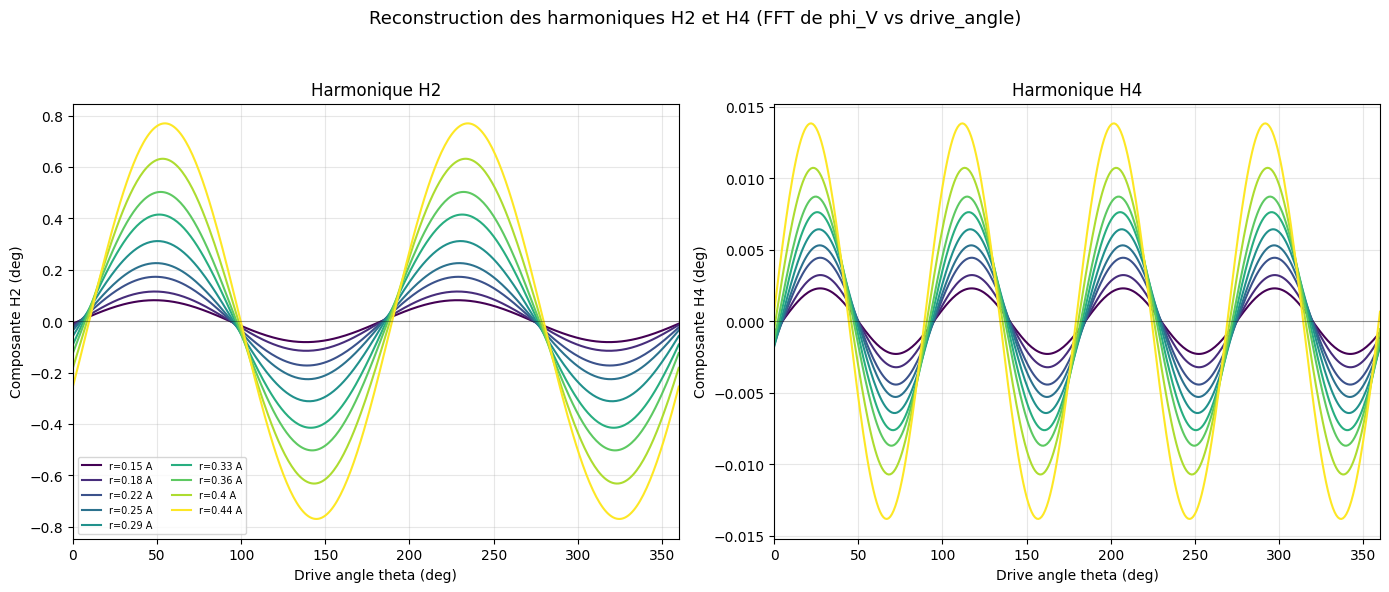

   r_A   A2 (deg)   phi2 (deg)   A4 (deg)   phi4 (deg)
  0.15     0.0815       -96.84     0.0023      -109.43
  0.18     0.1154       -97.24     0.0032      -109.91
  0.22     0.1726       -98.13     0.0044      -109.46
  0.25     0.2259       -99.09     0.0053      -108.43
  0.29     0.3117      -100.71     0.0064      -106.10
  0.33     0.4148      -102.66     0.0076      -102.42
  0.36     0.5029      -104.31     0.0087       -98.72
  0.40     0.6320      -106.71     0.0107       -92.95
  0.44     0.7698      -109.33     0.0138       -87.27


In [18]:
N_drive = len(drive_angle_deg)
theta_dense_deg = np.linspace(0, 360, 361)
theta_dense_rad = np.radians(theta_dense_deg)
colors = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

harmonics = {}   # harmonics[r_A][k] = (A_k deg, phi_k rad)

for r_A in r_list_A:
    B_norm_T = r_A * COIL_GAIN_G_PER_A * 1e-4
    phi_raw = []
    for theta in drive_angle_deg:
        th = np.radians(theta)
        B_T = B_norm_T * np.array([np.cos(th), np.sin(th), Bz_shift])

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_V = rb85_bloch.polarization_intensities(E_out)['V']
        phase_rad, amp = physics._fit_phase(I_V)
        phi_raw.append(np.degrees(phase_rad))
    phi_raw = np.array(phi_raw)

    X = np.fft.rfft(phi_raw)
    harmonics[r_A] = {}
    for k in (2, 4):
        A_k = 2 * np.abs(X[k]) / N_drive
        phi_k = np.angle(X[k])
        harmonics[r_A][k] = (A_k, phi_k)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, k in zip(axs, (2, 4)):
    for r_A, color in zip(r_list_A, colors):
        A_k, phi_k = harmonics[r_A][k]
        curve = A_k * np.cos(k * theta_dense_rad + phi_k)
        ax.plot(theta_dense_deg, curve, color=color, label=f'r={r_A} A')
    ax.set_title(f'Harmonique H{k}')
    ax.set_xlabel('Drive angle theta (deg)')
    ax.set_ylabel(f'Composante H{k} (deg)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 360)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)

axs[0].legend(ncol=2, fontsize=7)
fig.suptitle('Reconstruction des harmoniques H2 et H4 (FFT de phi_V vs drive_angle)', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

print(f"{'r_A':>6}  {'A2 (deg)':>9}  {'phi2 (deg)':>11}  {'A4 (deg)':>9}  {'phi4 (deg)':>11}")
for r_A in r_list_A:
    A2, phi2 = harmonics[r_A][2]
    A4, phi4 = harmonics[r_A][4]
    print(f"{r_A:6.2f}  {A2:9.4f}  {np.degrees(phi2):11.2f}  {A4:9.4f}  {np.degrees(phi4):11.2f}")

### Amplitude et phase de H2/H4, séparément, en fonction de r_A

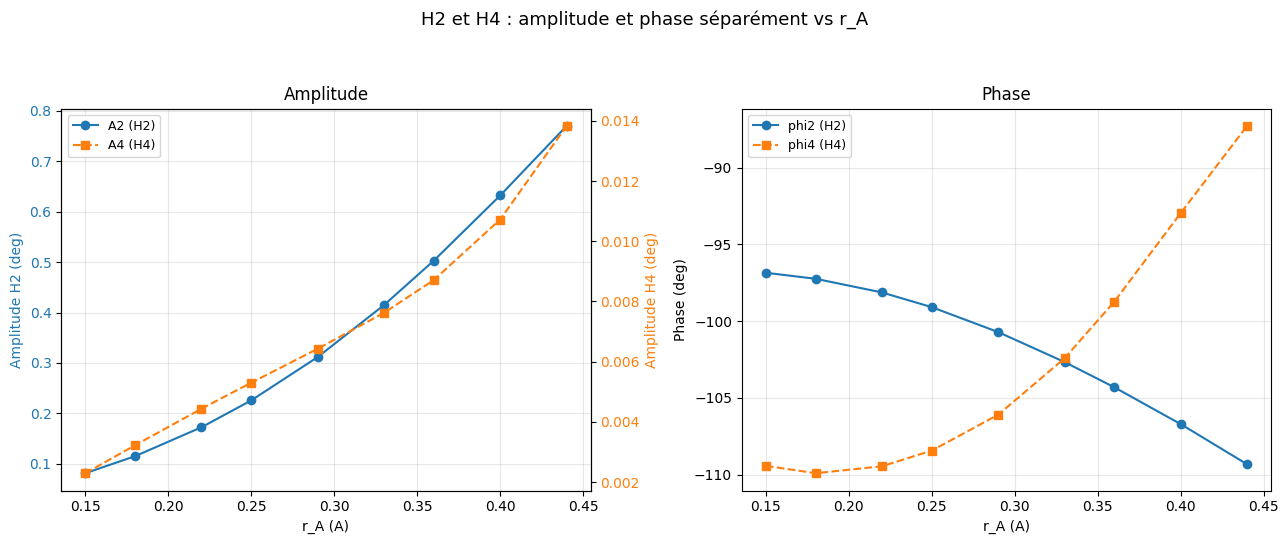

In [19]:
A2_list = np.array([harmonics[r_A][2][0] for r_A in r_list_A])
A4_list = np.array([harmonics[r_A][4][0] for r_A in r_list_A])
phi2_deg_list = np.degrees([harmonics[r_A][2][1] for r_A in r_list_A])
phi4_deg_list = np.degrees([harmonics[r_A][4][1] for r_A in r_list_A])

fig, (ax_amp, ax_phase) = plt.subplots(1, 2, figsize=(13, 5.5))

ax_amp.plot(r_list_A, A2_list, 'o-', color='tab:blue', label='A2 (H2)')
ax_amp.set_xlabel('r_A (A)')
ax_amp.set_ylabel('Amplitude H2 (deg)', color='tab:blue')
ax_amp.tick_params(axis='y', labelcolor='tab:blue')
ax_amp.grid(True, alpha=0.3)

ax_amp2 = ax_amp.twinx()
ax_amp2.plot(r_list_A, A4_list, 's--', color='tab:orange', label='A4 (H4)')
ax_amp2.set_ylabel('Amplitude H4 (deg)', color='tab:orange')
ax_amp2.tick_params(axis='y', labelcolor='tab:orange')
ax_amp.set_title('Amplitude')

lines1, labels1 = ax_amp.get_legend_handles_labels()
lines2, labels2 = ax_amp2.get_legend_handles_labels()
ax_amp.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax_phase.plot(r_list_A, phi2_deg_list, 'o-', color='tab:blue', label='phi2 (H2)')
ax_phase.plot(r_list_A, phi4_deg_list, 's--', color='tab:orange', label='phi4 (H4)')
ax_phase.set_xlabel('r_A (A)')
ax_phase.set_ylabel('Phase (deg)')
ax_phase.set_title('Phase')
ax_phase.grid(True, alpha=0.3)
ax_phase.legend(fontsize=9)

fig.suptitle('H2 et H4 : amplitude et phase séparément vs r_A', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### Vérification : signal réel vs reconstruction DC+H2 puis DC+H2+H4

Le vrai signal `phi_V(drive_angle)` (points), et ce que donne sa reconstruction en ne gardant que la moyenne (DC), puis DC+H2, puis DC+H2+H4 -- pour voir directement ce que H2 et H4 apportent chacun.

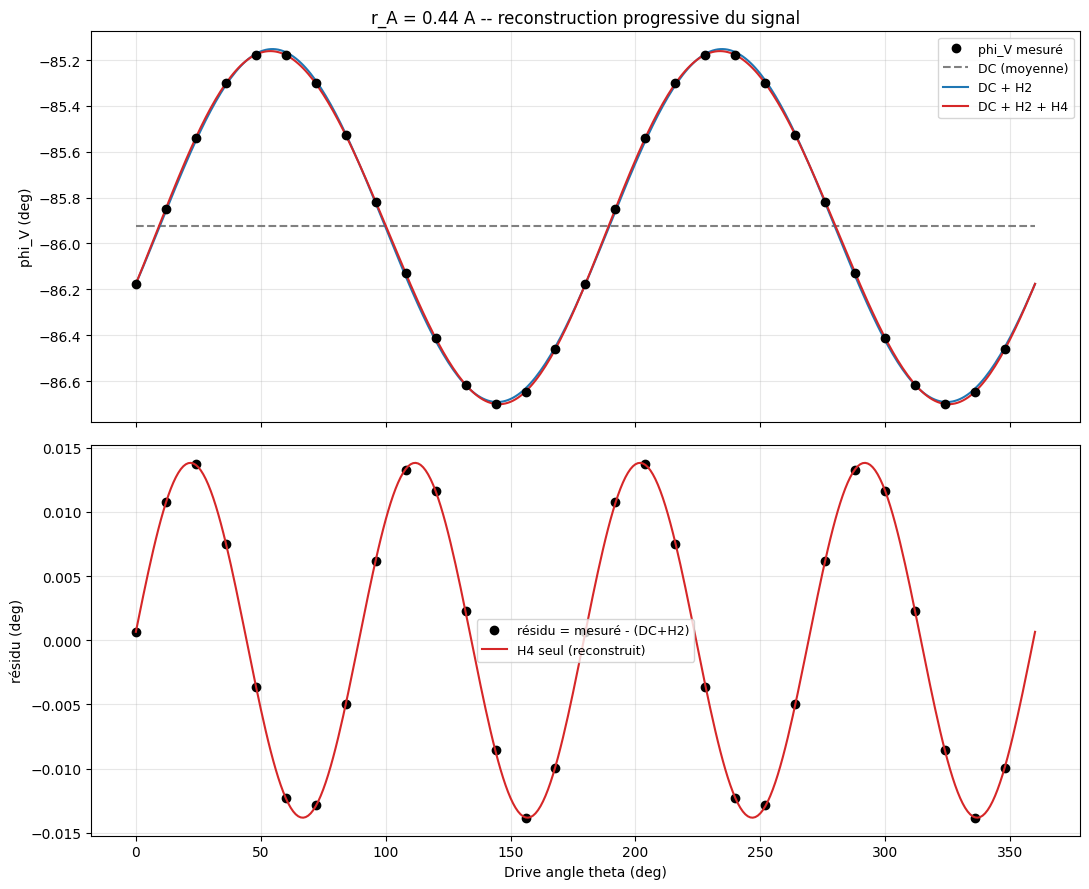

In [20]:
r_A_demo = r_list_A[-1]   # r_A avec le plus grand effet, pour bien voir
B_norm_T_demo = r_A_demo * COIL_GAIN_G_PER_A * 1e-4

phi_raw_demo = []
for theta in drive_angle_deg:
    th = np.radians(theta)
    B_T = B_norm_T_demo * np.array([np.cos(th), np.sin(th), Bz_shift])
    J = rb85_bloch.jones_matrix_closed(
        probe_det_rad, B_T, pump_s, L_cell, n_rho,
        pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
    )
    E_out = np.einsum('ij,tj->ti', J[0], E_in)
    I_V = rb85_bloch.polarization_intensities(E_out)['V']
    phase_rad, amp = physics._fit_phase(I_V)
    phi_raw_demo.append(np.degrees(phase_rad))
phi_raw_demo = np.array(phi_raw_demo)

X_demo = np.fft.rfft(phi_raw_demo)
dc = X_demo[0].real / N_drive
A2_demo, phi2_demo = harmonics[r_A_demo][2]
A4_demo, phi4_demo = harmonics[r_A_demo][4]

recon_dc = np.full_like(theta_dense_deg, dc)
recon_dc_h2 = dc + A2_demo * np.cos(2 * theta_dense_rad + phi2_demo)
recon_dc_h2_h4 = recon_dc_h2 + A4_demo * np.cos(4 * theta_dense_rad + phi4_demo)

# résidu mesuré (donnée - DC - H2) : doit coïncider avec la pure sinusoïde H4
residual_demo = phi_raw_demo - dc - A2_demo * np.cos(2 * np.radians(drive_angle_deg) + phi2_demo)
h4_only_dense = A4_demo * np.cos(4 * theta_dense_rad + phi4_demo)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

ax_top.plot(drive_angle_deg, phi_raw_demo, 'o', color='black', label='phi_V mesuré', zorder=5)
ax_top.plot(theta_dense_deg, recon_dc, '--', color='gray', label='DC (moyenne)')
ax_top.plot(theta_dense_deg, recon_dc_h2, '-', color='tab:blue', label='DC + H2')
ax_top.plot(theta_dense_deg, recon_dc_h2_h4, '-', color='tab:red', label='DC + H2 + H4')
ax_top.set_ylabel('phi_V (deg)')
ax_top.set_title(f'r_A = {r_A_demo} A -- reconstruction progressive du signal')
ax_top.legend(fontsize=9)
ax_top.grid(True, alpha=0.3)

ax_bot.plot(drive_angle_deg, residual_demo, 'o', color='black', label='résidu = mesuré - (DC+H2)')
ax_bot.plot(theta_dense_deg, h4_only_dense, '-', color='tab:red', label='H4 seul (reconstruit)')
ax_bot.set_xlabel('Drive angle theta (deg)')
ax_bot.set_ylabel('résidu (deg)')
ax_bot.legend(fontsize=9)
ax_bot.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Harmoniques H2/H4 de la fringe I(theta_cut) elle-même (pas de phi_V(drive_angle))

Cette fois la FFT porte directement sur le signal I(theta_cut) (le même type de courbe que la section "Intensité angulaire" ci-dessus), pas sur la phase extraite. Pour chaque `r_A` (3 normes déjà choisies) et chaque `drive_angle` (couleur `hsv`, comme avant), on extrait H2 et H4 de `I_V(theta_cut)` et on trace ces deux composantes reconstruites.

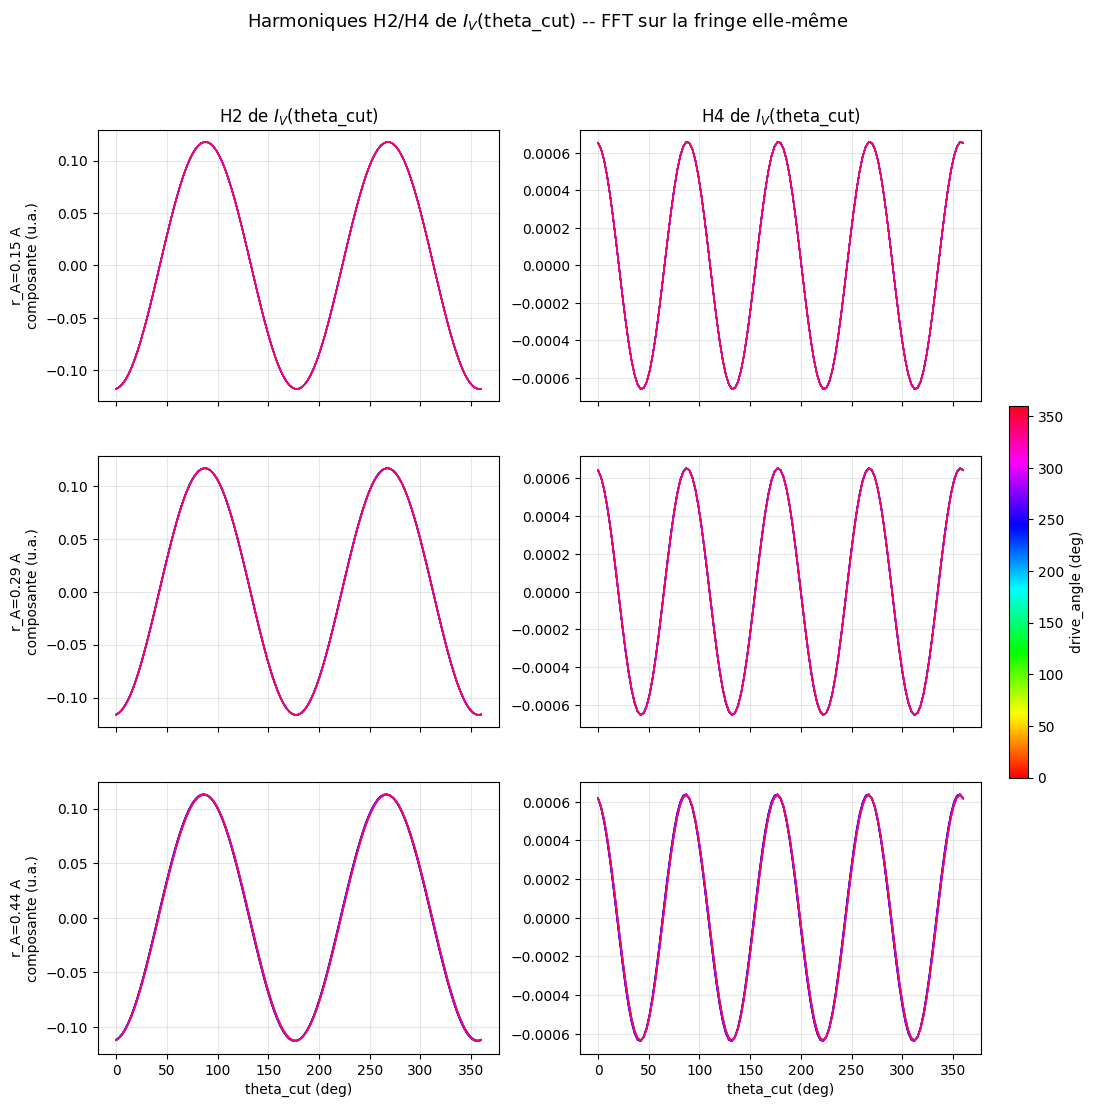

In [21]:
theta_cut_deg_grid = np.degrees(physics.theta_values)
N_cut = len(physics.theta_values)
ch_sig = 'V'

fig, axs = plt.subplots(len(r_A_sel), 2, figsize=(12, 4 * len(r_A_sel)), sharex=True)

for row, r_A in enumerate(r_A_sel):
    B_norm_T = r_A * COIL_GAIN_G_PER_A * 1e-4
    for theta in drive_angle_deg:
        color = plt.cm.hsv(theta / 360.0)
        th = np.radians(theta)
        B_T = B_norm_T * np.array([np.cos(th), np.sin(th), Bz_shift])

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_sig = rb85_bloch.polarization_intensities(E_out)[ch_sig]

        X = np.fft.rfft(I_sig)
        for col, k in enumerate((2, 4)):
            A_k = 2 * np.abs(X[k]) / N_cut
            phi_k = np.angle(X[k])
            curve = A_k * np.cos(k * physics.theta_values + phi_k)
            axs[row, col].plot(theta_cut_deg_grid, curve, color=color, linewidth=1.0, alpha=0.7)

for row, r_A in enumerate(r_A_sel):
    axs[row, 0].set_ylabel(f'r_A={r_A} A\ncomposante (u.a.)')
for col, k in enumerate((2, 4)):
    axs[0, col].set_title(f'H{k} de $I_{{{ch_sig}}}$(theta_cut)')
    axs[-1, col].set_xlabel('theta_cut (deg)')
for ax in axs.flat:
    ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap='hsv', norm=plt.Normalize(0, 360))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.03)
cbar.set_label('drive_angle (deg)')

fig.suptitle(f"Harmoniques H2/H4 de $I_{{{ch_sig}}}$(theta_cut) -- FFT sur la fringe elle-même", fontsize=13)
plt.show()

### Amplitude de H2 et H4 (de I_V(theta_cut)) en fonction de drive_angle, pour chaque r_A

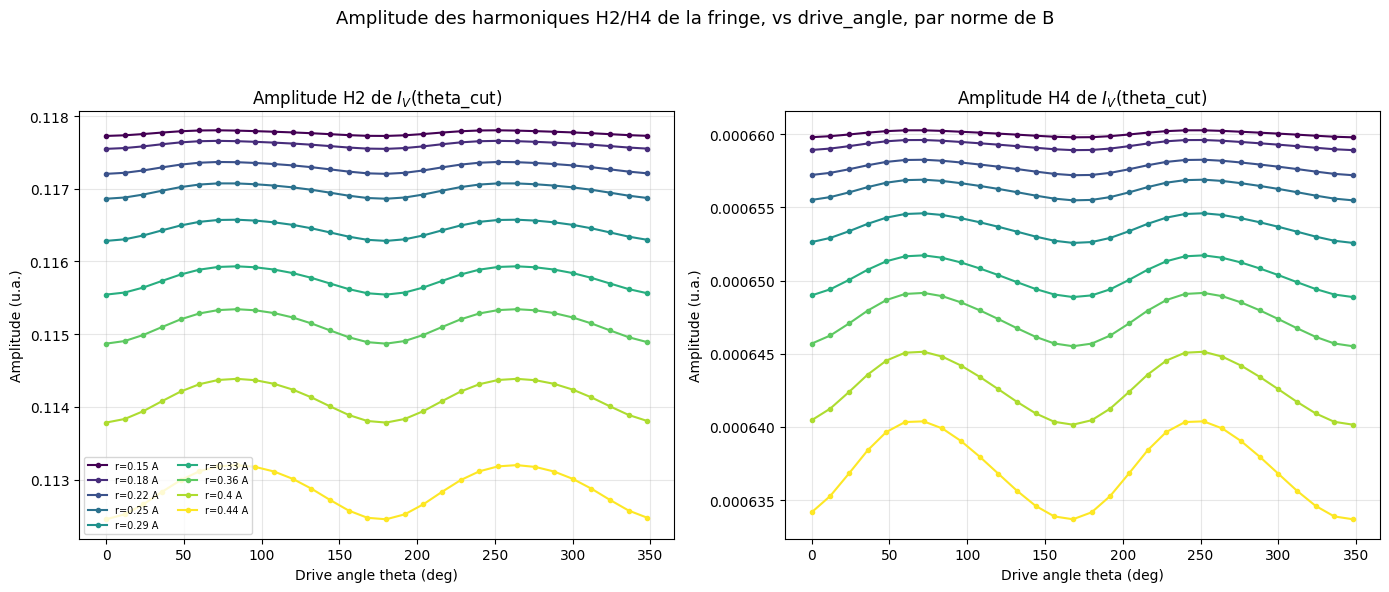

In [22]:
N_cut = len(physics.theta_values)
ch_sig = 'V'
colors = plt.cm.viridis(np.linspace(0, 1, len(r_list_A)))

amp2_of = {r_A: [] for r_A in r_list_A}
amp4_of = {r_A: [] for r_A in r_list_A}

for r_A in r_list_A:
    B_norm_T = r_A * COIL_GAIN_G_PER_A * 1e-4
    for theta in drive_angle_deg:
        th = np.radians(theta)
        B_T = B_norm_T * np.array([np.cos(th), np.sin(th), Bz_shift])

        J = rb85_bloch.jones_matrix_closed(
            probe_det_rad, B_T, pump_s, L_cell, n_rho,
            pump_detuning=pump_det_rad, gamma_t=gamma_t, pump_pol=pump_pol,
        )
        E_out = np.einsum('ij,tj->ti', J[0], E_in)
        I_sig = rb85_bloch.polarization_intensities(E_out)[ch_sig]

        X = np.fft.rfft(I_sig)
        amp2_of[r_A].append(2 * np.abs(X[2]) / N_cut)
        amp4_of[r_A].append(2 * np.abs(X[4]) / N_cut)

    amp2_of[r_A] = np.array(amp2_of[r_A])
    amp4_of[r_A] = np.array(amp4_of[r_A])

fig, (ax2, ax4) = plt.subplots(1, 2, figsize=(14, 6))

for r_A, color in zip(r_list_A, colors):
    ax2.plot(drive_angle_deg, amp2_of[r_A], marker='o', markersize=3, color=color, label=f'r={r_A} A')
    ax4.plot(drive_angle_deg, amp4_of[r_A], marker='o', markersize=3, color=color, label=f'r={r_A} A')

ax2.set_title(f'Amplitude H2 de $I_{{{ch_sig}}}$(theta_cut)')
ax4.set_title(f'Amplitude H4 de $I_{{{ch_sig}}}$(theta_cut)')
for ax in (ax2, ax4):
    ax.set_xlabel('Drive angle theta (deg)')
    ax.set_ylabel('Amplitude (u.a.)')
    ax.grid(True, alpha=0.3)
ax2.legend(ncol=2, fontsize=7)

fig.suptitle('Amplitude des harmoniques H2/H4 de la fringe, vs drive_angle, par norme de B', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()